> <p><small>This notebook is made available subject to the licence and terms set out in <a href="https://creativecommons.org/licenses/by/4.0">https://creativecommons.org/licenses/by/4.0</a>.</small></p>

<img src="https://pub-bba109a9a6ac49e3b428cdca19c34363.r2.dev/LT%20-%20Session%206.jpg" />

# 6.6 AI Long Activity 1 – Lab: Implement learning from interaction

Implement simple learning strategies in a simulated environment and compare their performance.

60 minutes

### Overview
In this notebook you will implement and analyse a simple feedback-driven learning algorithm. You will observe how different exploration strategies influence learning performance.
This activity helps students understand how simple learning strategies behave when rewards are uncertain.

### Pedagogical goal
Students should leave this lab with a clear intuition for:
- learning through interaction
- uncertainty in rewards
- exploration vs exploitation
- why a mixed strategy can outperform both pure randomness and pure greed.

## Teaching protocol

At each stage students should:
**Observe → Predict → Run → Explain**.

Encourage the students to not simply execute cells. They should form expectations, test them, and then interpret what happened.





### Important note
This notebook uses a very simple simulation. The goal is not formal bandit theory, but intuition about reinforcement learning from feedback.

### Task for students
1. Observe the provided example.
2. Complete the missing code.
3. Run experiments with different exploration rates.
4. Reflect on the results.

## Step 1 – Set up the environment

We imagine three possible actions. Each action gives a reward of 1 with some hidden probability.

### Interpretation
- The learner does **not** know these probabilities in advance.
- The learner must discover, through repeated interaction, which action is best.

### Teacher prompt
Ask:
- *If you had no information, how would you begin?*
- *Would you always repeat the first good option you find?*


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# Hidden reward probabilities for the three options.
probs = [0.2, 0.5, 0.8]


def pull(action: int) -> int:
    """Return 1 with probability probs[action], otherwise 0."""
    return 1 if np.random.rand() < probs[action] else 0


probs

[0.2, 0.5, 0.8]

## Step 2 – Warm-up: uncertain outcomes

Before introducing strategies, it is useful to see that the same action can give different rewards on different attempts.

### Key idea
A single bad outcome does **not** necessarily mean the action is bad.
A single good outcome does **not** necessarily mean the action is best.

This is the core challenge of learning under uncertainty.


In [ ]:
for action in range(3):
    samples = [pull(action) for _ in range(10)]
    print(f"Action {action}: {samples}")

Action 0: [0, 0, 0, 0, 1, 1, 1, 0, 0, 0]
Action 1: [1, 0, 0, 1, 1, 1, 1, 0, 1, 1]
Action 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Step 3 – Strategy 1: random choice

This strategy chooses an action uniformly at random at every round.

### Prediction prompt
> 👉 **Ask students:**
> - *Will this strategy eventually find the best option?*
> - *Even if it does, will it exploit that knowledge?*

### Interpretation
Random choice explores continuously, but it does not commit to good actions.


In [ ]:
def random_strategy(n_rounds: int = 100):
    """Run a strategy that selects actions randomly."""
    rewards = []
    actions = []

    for _ in range(n_rounds):
        action = np.random.randint(0, len(probs))
        reward = pull(action)
        actions.append(action)
        rewards.append(reward)

    return (
        np.array(actions),
        np.array(rewards),
        np.cumsum(rewards),
    )


random_actions, random_rewards, random_cum = random_strategy()

random_cum[-10:]

array([51, 52, 53, 54, 54, 54, 54, 54, 55, 56])

## Step 4 – Strategy 2: greedy choice

This strategy first samples each action once, then always chooses the action with the highest observed average reward so far.

### Prediction prompt
> 👉 **Ask students:**
> - Why might this strategy do very well?
> - Why might it fail badly?

### Key insight
A greedy strategy can become trapped by early luck.
If it gets a misleading early result, it may stop exploring too soon.


In [ ]:
def greedy_strategy(n_rounds: int = 100):
    """Run a greedy strategy using estimated action rewards."""
    estimates = np.zeros(len(probs))
    counts = np.zeros(len(probs))
    rewards = []
    actions = []

    for t in range(n_rounds):
        if t < len(probs):
            action = t  # Initial exploration.
        else:
            action = int(np.argmax(estimates))

        reward = pull(action)
        actions.append(action)
        rewards.append(reward)

        counts[action] += 1
        estimates[action] += (reward - estimates[action]) / counts[action]

    return (
        np.array(actions),
        np.array(rewards),
        np.cumsum(rewards),
        estimates,
        counts,
    )


(
    greedy_actions,
    greedy_rewards,
    greedy_cum,
    greedy_estimates,
    greedy_counts,
) = greedy_strategy()

greedy_estimates, greedy_counts

(array([0.        , 0.        , 0.78571429]), array([ 1.,  1., 98.]))

## Step 5 – Strategy 3: epsilon-greedy

This strategy is mostly greedy, but with a small probability it explores a random action.

### Why this matters
This is a simple way to balance:
- **exploitation**: using the best-known action
- **exploration**: checking whether another action might be better

### Prediction prompt
> 👉 **Ask students:**
> - Why might a small amount of exploration help?
> - Could too much exploration hurt?


In [ ]:
def epsilon_greedy(epsilon: float = 0.1, n_rounds: int = 100):
    """Run an epsilon-greedy strategy using estimated action rewards."""
    estimates = np.zeros(len(probs))
    counts = np.zeros(len(probs))
    rewards = []
    actions = []

    for t in range(n_rounds):
        if t < len(probs):
            action = t
        elif np.random.rand() < epsilon:
            action = np.random.randint(len(probs))
        else:
            action = int(np.argmax(estimates))

        reward = pull(action)
        actions.append(action)
        rewards.append(reward)

        counts[action] += 1
        estimates[action] += (reward - estimates[action]) / counts[action]

    return (
        np.array(actions),
        np.array(rewards),
        np.cumsum(rewards),
        estimates,
        counts,
    )


(
    eps_actions,
    eps_rewards,
    eps_cum,
    eps_estimates,
    eps_counts,
) = epsilon_greedy(epsilon=0.1)

eps_estimates, eps_counts

(array([0.        , 0.33333333, 0.75280899]), array([ 5.,  6., 89.]))

## Step 6 – Compare cumulative rewards

Now we compare how much total reward each strategy collected over time.

### Interpretation prompt
> 👉 **Ask students:**
> - Which strategy starts strongly?
> - Which one improves over time?
> - Which strategy seems most robust?


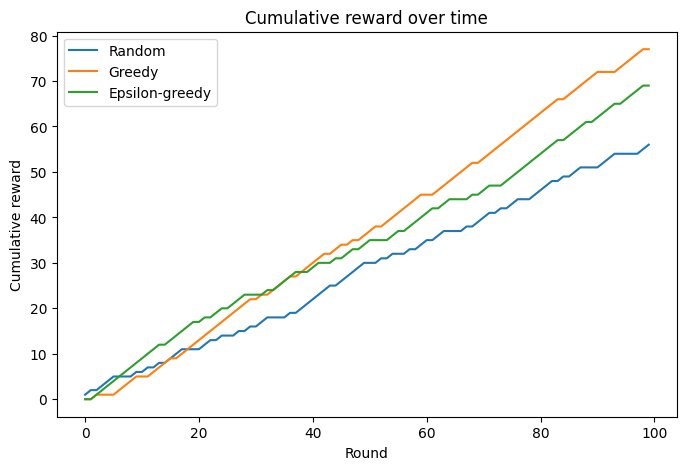

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(random_cum, label="Random")
plt.plot(greedy_cum, label="Greedy")
plt.plot(eps_cum, label="Epsilon-greedy")
plt.xlabel("Round")
plt.ylabel("Cumulative reward")
plt.title("Cumulative reward over time")
plt.legend()
plt.show()

## Step 7 – Compare action frequencies

It is not enough to know the total reward. We also want to know **how** each strategy behaved.

### Why this matters
The frequency of chosen actions reveals:
- whether the strategy explored
- whether it committed too early
- whether it discovered the best option


In [ ]:
def action_counts(actions):
    """Count how often each action was selected."""
    return {
        a: int((actions == a).sum())
        for a in range(len(probs))
    }


print("Random:", action_counts(random_actions))
print("Greedy:", action_counts(greedy_actions))
print("Epsilon-greedy:", action_counts(eps_actions))

Random: {0: 32, 1: 31, 2: 37}
Greedy: {0: 1, 1: 1, 2: 98}
Epsilon-greedy: {0: 5, 1: 6, 2: 89}


## Step 8 – Repeat the experiment many times

A single run can be misleading because rewards are random.

### Key idea
To compare strategies properly, we should repeat the experiment and average results.

This is an important scientific habit:
> do not trust one lucky or unlucky run


In [ ]:
def run_many(strategy_fn, n_runs=100, n_rounds=100, **kwargs):
    """Run a strategy many times and return final cumulative rewards."""
    final_rewards = []

    for _ in range(n_runs):
        if kwargs:
            result = strategy_fn(n_rounds=n_rounds, **kwargs)
        else:
            result = strategy_fn(n_rounds=n_rounds)

        final_rewards.append(result[2][-1])  # Cumulative reward at the end.

    return np.array(final_rewards)


random_many = run_many(random_strategy, n_runs=200)
greedy_many = run_many(greedy_strategy, n_runs=200)
eps_many = run_many(epsilon_greedy, n_runs=200, epsilon=0.1)

print("Average final reward")
print("Random:", random_many.mean())
print("Greedy:", greedy_many.mean())
print("Epsilon-greedy:", eps_many.mean())

Average final reward
Random: 49.255
Greedy: 68.78
Epsilon-greedy: 69.935


## Step 9 – Visualize repeated runs

This plot gives a better basis for comparison.

### Teacher prompt
> 👉 **Ask students:**
> - Does your conclusion change when you average over many runs?
> - Which strategy is most reliable?


/var/folders/p6/p7r4cs816ql1b71nd15wm0t40000gn/T/ipykernel_32319/3907554269.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([random_many, greedy_many, eps_many], labels=["Random", "Greedy", "Epsilon-greedy"])


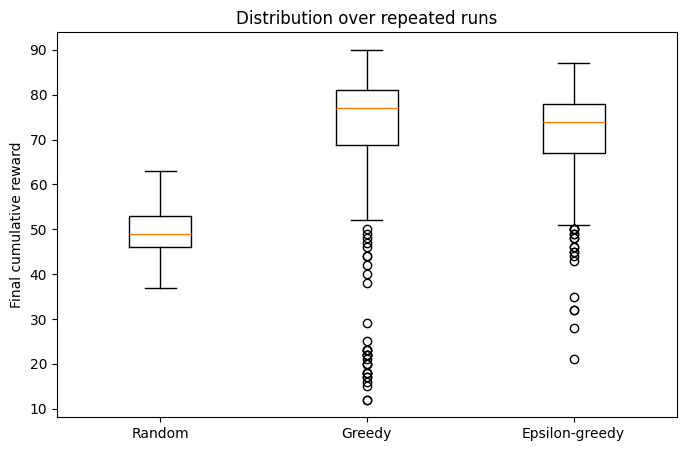

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [random_many, greedy_many, eps_many],
    tick_labels=["Random", "Greedy", "Epsilon-greedy"],
)
plt.ylabel("Final cumulative reward")
plt.title("Distribution over repeated runs")
plt.show()

## Step 10 – Change the exploration rate

Now we test several epsilon values.

### Prediction prompt
> 👉 **Ask students:**
> - What if exploration is too low?
> - What if exploration is too high?

### Key idea
There is often no universally best exploration rate.
Performance depends on the environment and time horizon.


In [ ]:
epsilons = [0.01, 0.1, 0.3]
results = {}

for eps in epsilons:
    results[eps] = run_many(
        epsilon_greedy,
        n_runs=200,
        n_rounds=100,
        epsilon=eps,
    ).mean()

results

{0.01: np.float64(69.555), 0.1: np.float64(70.915), 0.3: np.float64(68.075)}

## Step 11 – Optional extension: changing rewards over time

In many real systems, the environment is not fixed. Preferences and outcomes can change.

Here we simulate a changing world:
- initially, action 2 is best
- later, action 1 becomes better

### Why this matters
A strategy that never explores may fail badly when conditions change.
This connects to real recommendation systems and user behaviour.


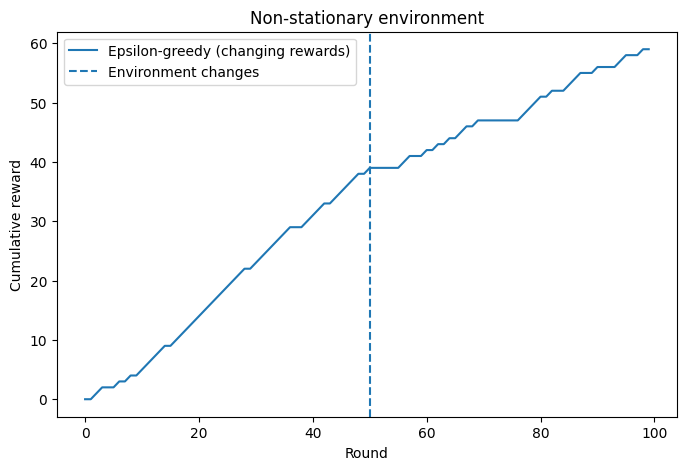

In [ ]:
def pull_nonstationary(action: int, t: int) -> int:
    """Return a reward from a changing environment."""
    if t < 50:
        dynamic_probs = [0.2, 0.5, 0.8]
    else:
        dynamic_probs = [0.2, 0.9, 0.4]

    return 1 if np.random.rand() < dynamic_probs[action] else 0


def epsilon_greedy_nonstationary(
    epsilon: float = 0.1,
    n_rounds: int = 100,
):
    """Run epsilon-greedy in a non-stationary environment."""
    estimates = np.zeros(3)
    counts = np.zeros(3)
    rewards = []
    actions = []

    for t in range(n_rounds):
        if t < 3:
            action = t
        elif np.random.rand() < epsilon:
            action = np.random.randint(3)
        else:
            action = int(np.argmax(estimates))

        reward = pull_nonstationary(action, t)
        actions.append(action)
        rewards.append(reward)

        counts[action] += 1
        estimates[action] += (reward - estimates[action]) / counts[action]

    return (
        np.array(actions),
        np.array(rewards),
        np.cumsum(rewards),
    )


(
    nonstat_actions,
    nonstat_rewards,
    nonstat_cum,
) = epsilon_greedy_nonstationary(epsilon=0.1)

plt.figure(figsize=(8, 5))
plt.plot(nonstat_cum, label="Epsilon-greedy (changing rewards)")
plt.axvline(50, linestyle="--", label="Environment changes")
plt.xlabel("Round")
plt.ylabel("Cumulative reward")
plt.title("Non-stationary environment")
plt.legend()
plt.show()

## Final reflection

Students should now be able to explain:

1. Why pure randomness is weak  
2. Why pure greed can fail  
3. Why some exploration is useful  
4. Why repeated runs are important  
5. Why changing environments make the problem harder  

## Suggested teacher closing message

Learning from interaction is not only about collecting reward.
It is about balancing:
- short-term reward
- information gathering
- adaptation over time

This is one of the central ideas behind reinforcement learning.
